<table align="left">
  <td><a target="_blank" href="https://colab.research.google.com/github/anvasquezre/EAFIT_AA_2026-02/blob/main/notebooks/04_ml_recomendadores_shap.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a></td>
  <td><a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/anvasquezre/EAFIT_AA_2026-02/blob/main/notebooks/04_ml_recomendadores_shap.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Abrir en Kaggle"/></a></td>
</table>
<br><br>

# Recomendadores e interpretabilidad: ALS, híbridos y SHAP

**Curso:** Aprendizaje Automático — SI7009 - 1 (5553)
**Sesión 4:** Recomendadores e interpretabilidad
**Universidad:** EAFIT
**Profesor:** Andrés Vásquez Restrepo
**Dataset:** MovieLens 1M (GroupLens): 1M ratings, 6.040 usuarios, 3.706 películas

---

**Objetivo:** entender, con las manos, cómo un sistema decide qué mostrarle a cada persona. Primero en un **mini-mundo** de 5 personas y 6 películas que se resuelve con lápiz; después, las mismas ideas sobre 1 millón de ratings reales.

### Cómo trabajar este notebook

Esto es un **cuaderno guiado**, no un listado de código. El código pesado (descargas, métricas, gráficos) está en una celda de herramientas que solo hay que ejecutar.

| Marca | Qué hacer |
|---|---|
| 🔮 **Prediga** | antes de ejecutar, diga qué espera que pase |
| 📝 **Ejemplo resuelto** | la cuenta de la teoría hecha paso a paso; repítala con lápiz y compare |
| 💬 **Discuta** | pregunta para responder en parejas; la respuesta va debajo |

### Glosario de 1 minuto

| Término | Qué significa aquí |
|---|---|
| **usuario / ítem** | una persona / una película |
| **interacción** | el usuario vio una película y le gustó |
| **score** | número que el modelo da a un par (usuario, película); mayor = mostrar antes |
| **top-$k$** | las $k$ películas de mayor score que el usuario **no** ha visto |
| **basado en contenido** | recomienda por los **atributos de la película** (géneros) |
| **filtrado colaborativo** | recomienda por el **comportamiento de otros usuarios** |
| **híbrido** | combina ambas señales |

### Mapa

| Sección | Pregunta | Ejemplos |
|---|---|---|
| 3. Mini-mundo | ¿Qué hace cada método en un ejemplo que cabe en una pantalla? | 1–7 |
| 4. Datos reales | ¿Cómo se ven 1 millón de ratings? | 8 |
| 5. Evaluar | ¿Cómo medir sin hacer trampa con el futuro? | 9 |
| 6. Baselines | ¿Qué hay que superar? | 10 |
| 7. ALS | ¿Cómo aprende el modelo colaborativo? | 11–12 |
| 8. Híbridos | ¿Ayuda sumar el contenido? | 13 |
| 9. SHAP | ¿Por qué el modelo ordenó así? | 14–15 |

<a name="1"></a>
## 1. Cómo ejecutar

**Local con `uv`**, desde la raíz del repositorio: `uv sync` y luego `uv run jupyter lab notebooks/04_ml_recomendadores_shap.ipynb`.

**Colab / Kaggle:** ejecutar la celda siguiente (instala `shap` y `lightgbm`). El dataset (~6 MB) se descarga solo de GroupLens.

In [1]:
import os
import subprocess
import sys

if "google.colab" in sys.modules or "KAGGLE_KERNEL_RUN_TYPE" in os.environ:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "shap", "lightgbm", "scikit-learn>=1.5"], check=True)
    print("Cloud environment: dependencies installed.")
else:
    print("Local environment: dependencies come from pyproject.toml / uv.lock (run `uv sync`).")

Local environment: dependencies come from pyproject.toml / uv.lock (run `uv sync`).


<a name="2"></a>
## 2. Herramientas de la sesión

Ejecute la celda siguiente (está plegada). Contiene descarga de datos, métricas, el split, ALS y gráficos. **No hace falta leerla**: cada función que usemos se explica cuando aparece. Si tiene curiosidad, despliéguela.

In [2]:
#@title Herramientas de la sesión (ejecutar; no hace falta leer)
from __future__ import annotations

import io
import urllib.request
import warnings
import zipfile
from itertools import combinations
from math import factorial
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
from IPython.display import display
from lightgbm import LGBMRanker
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
RANDOM_STATE = 42
FAST_DEMO_MODE = True
K = 10                          # length of the recommendation list
N_TEST, N_VAL = 5, 5            # last positives of each user for test / validation
N_CANDIDATES = 100              # candidates per user for the re-ranker
ALS_ITERATIONS = 8 if FAST_DEMO_MODE else 15

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
DECK_FIGURES = Path("../lectures/latex/04_ml_recommender_shap/figures")   # figures go to the slides when present
FIG_DIR = DECK_FIGURES if DECK_FIGURES.exists() else Path("figures_out")
FIG_DIR.mkdir(exist_ok=True)
plt.rcParams.update({"figure.figsize": (9, 4.8), "font.size": 11, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False})
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


# ----------------------------------------------------------------------------- ranking metrics
def precision_at_k(recs: dict, truth: dict, k: int = K) -> float:
    return float(np.mean([len(set(recs[u][:k]) & truth[u]) / k for u in truth]))


def recall_at_k(recs: dict, truth: dict, k: int = K) -> float:
    return float(np.mean([len(set(recs[u][:k]) & truth[u]) / len(truth[u]) for u in truth]))


def ndcg_at_k(recs: dict, truth: dict, k: int = K) -> float:
    discounts = 1.0 / np.log2(np.arange(2, k + 2))
    scores = []
    for u, rel in truth.items():
        gains = np.array([1.0 if i in rel else 0.0 for i in recs[u][:k]])
        scores.append((gains * discounts[: len(gains)]).sum() / discounts[: min(len(rel), k)].sum())
    return float(np.mean(scores))


def coverage(recs: dict, n_items: int, k: int = K) -> float:
    return len({i for u in recs for i in recs[u][:k]}) / n_items


def evaluate(name: str, recs: dict, truth: dict, n_items: int) -> dict:
    return {"model": name, f"precision@{K}": precision_at_k(recs, truth), f"recall@{K}": recall_at_k(recs, truth),
            f"ndcg@{K}": ndcg_at_k(recs, truth), "coverage": coverage(recs, n_items)}


def top_k_from_scores(scores: np.ndarray, seen: sp.csr_matrix, users, k: int = K) -> dict:
    """Top-k items per user from a (users x items) score matrix, excluding items seen in train."""
    scores = np.array(scores, dtype=float, copy=True)
    recs = {}
    for row, u in enumerate(users):
        scores[row, seen[u].indices] = -np.inf
        top = np.argpartition(-scores[row], k)[:k]
        recs[u] = list(top[np.argsort(-scores[row, top])])
    return recs


# ----------------------------------------------------------------------------- MovieLens
ML = None


def load_movielens() -> SimpleNamespace:
    """Download MovieLens 1M once, map ids to contiguous indices and build genre vectors."""
    global ML
    zip_path = DATA_DIR / "ml-1m.zip"
    if not zip_path.exists():
        urllib.request.urlretrieve("https://files.grouplens.org/datasets/movielens/ml-1m.zip", zip_path)

    def read_dat(name, columns):
        with zipfile.ZipFile(zip_path) as zf:
            raw = zf.read(f"ml-1m/{name}").decode("latin-1")
        return pd.read_csv(io.StringIO(raw), sep="::", engine="python", names=columns)

    ratings = read_dat("ratings.dat", ["user_id", "movie_id", "rating", "timestamp"])
    movies = read_dat("movies.dat", ["movie_id", "title", "genres"])
    users = read_dat("users.dat", ["user_id", "gender", "age", "occupation", "zip"])
    user_ids, item_ids = np.sort(ratings["user_id"].unique()), np.sort(ratings["movie_id"].unique())
    uidx, iidx = {u: k for k, u in enumerate(user_ids)}, {i: k for k, i in enumerate(item_ids)}
    ratings["u"], ratings["i"] = ratings["user_id"].map(uidx), ratings["movie_id"].map(iidx)
    n_users, n_items = len(user_ids), len(item_ids)
    movies = movies[movies["movie_id"].isin(iidx)].assign(i=lambda d: d["movie_id"].map(iidx)).sort_values("i")
    movies["year"] = movies["title"].str.extract(r"\((\d{4})\)\s*$").astype(float)
    genres = sorted({g for gs in movies["genres"] for g in gs.split("|")})
    item_genres = np.zeros((n_items, len(genres)))
    for row in movies.itertuples():
        for g in row.genres.split("|"):
            item_genres[row.i, genres.index(g)] = 1.0
    uf = users.assign(u=users["user_id"].map(uidx)).set_index("u").reindex(range(n_users))
    ML = SimpleNamespace(
        ratings=ratings, movies=movies, users=users, user_ids=user_ids, n_users=n_users, n_items=n_items,
        genres=genres, item_genres=item_genres, titles=movies.set_index("i")["title"],
        R=sp.csr_matrix((ratings["rating"].astype(float), (ratings["u"], ratings["i"])), shape=(n_users, n_items)),
        user_age=uf["age"].to_numpy(dtype=float), user_gender=(uf["gender"] == "F").to_numpy(dtype=float),
        user_occ=uf["occupation"].to_numpy(dtype=float),
        item_year=movies.set_index("i")["year"].reindex(range(n_items)).to_numpy())
    return ML


def to_matrix(df: pd.DataFrame) -> sp.csr_matrix:
    return sp.csr_matrix((np.ones(len(df)), (df["u"], df["i"])), shape=(ML.n_users, ML.n_items))


def temporal_split(ratings: pd.DataFrame, threshold: int = 4) -> SimpleNamespace:
    """Implicit positives (rating >= threshold); per user, last N_TEST -> test, previous N_VAL -> validation."""
    pos = ratings[ratings["rating"] >= threshold].sort_values(["u", "timestamp"])
    pos = pos.groupby("u").filter(lambda d: len(d) >= N_TEST + N_VAL + 5)
    from_end = pos.groupby("u").cumcount(ascending=False)
    test_df = pos[from_end < N_TEST]
    val_df = pos[(from_end >= N_TEST) & (from_end < N_TEST + N_VAL)]
    train_df = pos[from_end >= N_TEST + N_VAL]
    val_truth = val_df.groupby("u")["i"].apply(set).to_dict()
    test_truth = test_df.groupby("u")["i"].apply(set).to_dict()
    return SimpleNamespace(pos=pos, train_df=train_df, val_df=val_df, test_df=test_df,
                           X_train=to_matrix(train_df), X_trainval=to_matrix(pd.concat([train_df, val_df])),
                           val_truth=val_truth, test_truth=test_truth,
                           val_users=np.array(sorted(val_truth)), eval_users=np.array(sorted(test_truth)))


# ----------------------------------------------------------------------------- scorers
def random_scores(X, users, seed=RANDOM_STATE):
    return np.random.default_rng(seed).random((len(users), X.shape[1]))


def popularity_scores(X, users):
    return np.tile(np.asarray(X.sum(axis=0)).ravel(), (len(users), 1))


def item_item_scores(X, users):
    norms = np.sqrt(np.asarray(X.multiply(X).sum(axis=0)).ravel()) + 1e-9
    Xn = X @ sp.diags(1.0 / norms)
    S = (Xn.T @ Xn).toarray()                       # item x item cosine similarity
    np.fill_diagonal(S, 0.0)
    return np.asarray(X[users] @ S)


def content_scores(X, users, item_genres=None):
    G = ML.item_genres if item_genres is None else item_genres
    profiles = np.asarray(X[users] @ G, dtype=float)
    profiles /= np.linalg.norm(profiles, axis=1, keepdims=True) + 1e-9
    return profiles @ (G / (np.linalg.norm(G, axis=1, keepdims=True) + 1e-9)).T


def minmax_rows(S):
    lo, hi = S.min(axis=1, keepdims=True), S.max(axis=1, keepdims=True)
    return (S - lo) / (hi - lo + 1e-9)


# ----------------------------------------------------------------------------- implicit ALS
def als_half_step(X: sp.csr_matrix, Y: np.ndarray, lam: float, alpha: float) -> np.ndarray:
    """Solve one side (rows of X) with the factors Y of the other side fixed."""
    f = Y.shape[1]
    YtY = Y.T @ Y                                    # V^T V: once for everybody
    out = np.zeros((X.shape[0], f))
    for row in range(X.shape[0]):
        idx = X.indices[X.indptr[row]:X.indptr[row + 1]]   # items seen by this row
        if len(idx) == 0:
            continue
        Yu = Y[idx]
        A = YtY + alpha * (Yu.T @ Yu) + lam * np.eye(f)   # c_ui - 1 = alpha on seen items
        b = (1.0 + alpha) * Yu.sum(axis=0)               # V^T C_u p_u
        out[row] = np.linalg.solve(A, b)
    return out


def implicit_loss(X, U, V, lam, alpha):
    rows, cols = X.nonzero()
    s_obs = np.einsum("ij,ij->i", U[rows], V[cols])
    all_sq = np.trace((U.T @ U) @ (V.T @ V))                  # every cell with p = 0, c = 1
    obs = ((1 + alpha) * (1 - s_obs) ** 2 - s_obs ** 2).sum()  # fix the observed cells
    return all_sq + obs + lam * ((U ** 2).sum() + (V ** 2).sum())


def fit_als(X, factors, lam, alpha, iterations=ALS_ITERATIONS, seed=RANDOM_STATE, track_loss=False):
    rng = np.random.default_rng(seed)
    U = rng.normal(scale=0.01, size=(X.shape[0], factors))
    V = rng.normal(scale=0.01, size=(X.shape[1], factors))
    Xt, losses = X.T.tocsr(), []
    for _ in range(iterations):
        U = als_half_step(X, V, lam, alpha)
        V = als_half_step(Xt, U, lam, alpha)
        if track_loss:
            losses.append(implicit_loss(X, U, V, lam, alpha))
    return (U, V, losses) if track_loss else (U, V)


# ----------------------------------------------------------------------------- re-ranker
FEATURES = ["als_score", "als_rank", "content_sim", "item_popularity", "item_year", "item_n_genres",
            "user_age", "user_gender_f", "user_occupation", "user_activity"]
FEATURE_GROUP = {"als_score": "colaborativa", "als_rank": "colaborativa", "content_sim": "par usuario–ítem",
                 "item_popularity": "ítem", "item_year": "ítem", "item_n_genres": "ítem",
                 "user_age": "usuario", "user_gender_f": "usuario", "user_occupation": "usuario",
                 "user_activity": "usuario"}


def candidate_frame(Uf, Vf, X_hist, users_, truth=None) -> pd.DataFrame:
    """Top-N_CANDIDATES ALS candidates per user (seen items removed) with ranking features and labels."""
    scores = Uf[users_] @ Vf.T
    cont = content_scores(X_hist, users_)
    pop = np.log1p(np.asarray(X_hist.sum(axis=0)).ravel())
    activity = np.log1p(np.asarray(X_hist.sum(axis=1)).ravel())
    frames = []
    for row, u in enumerate(users_):
        s = scores[row].copy()
        s[X_hist[u].indices] = -np.inf
        cand = np.argpartition(-s, N_CANDIDATES)[:N_CANDIDATES]
        cand = cand[np.argsort(-s[cand])]
        frames.append(pd.DataFrame({
            "u": u, "i": cand, "als_score": s[cand], "als_rank": np.arange(1, len(cand) + 1),
            "content_sim": cont[row, cand], "item_popularity": pop[cand], "item_year": ML.item_year[cand],
            "item_n_genres": ML.item_genres[cand].sum(axis=1), "user_age": ML.user_age[u],
            "user_gender_f": ML.user_gender[u], "user_occupation": ML.user_occ[u], "user_activity": activity[u],
            "label": [int(i in truth.get(u, ())) for i in cand] if truth is not None else 0}))
    return pd.concat(frames, ignore_index=True).sort_values(["u", "als_rank"])


# ----------------------------------------------------------------------------- Shapley by enumeration
def shapley(f, x: dict, ref: dict) -> dict:
    """Exact Shapley values: features outside the coalition take their reference value."""
    names, n = list(x), len(x)
    value = lambda S: f(**{k: (x[k] if k in S else ref[k]) for k in names})
    return {j: sum(factorial(len(S)) * factorial(n - len(S) - 1) / factorial(n) * (value(set(S) | {j}) - value(set(S)))
                   for r in range(n) for S in combinations([k for k in names if k != j], r))
            for j in names}


# ----------------------------------------------------------------------------- plots and views
def lists_side_by_side(user, recs_by_model: dict) -> pd.DataFrame:
    return pd.DataFrame({m: ML.titles.reindex(r[user][:K]).to_numpy() for m, r in recs_by_model.items()})


def plot_long_tail():
    counts = np.sort(np.asarray((ML.R > 0).sum(axis=0)).ravel())[::-1]
    top = int(0.1 * ML.n_items)
    share = counts[:top].sum() / counts.sum()
    x = np.arange(1, ML.n_items + 1)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(x, counts, color="#1A89C9")
    ax.fill_between(x, counts, alpha=0.25, color="#1A89C9")
    ax.axvline(top, ls="--", color="#A6040E")
    ax.text(top + 40, counts[0] * 0.8, f"top 10 % de las películas\n= {share:.0%} de los ratings", color="#A6040E")
    ax.set(title="Cola larga: ratings por película (ordenadas)", xlabel="películas ordenadas por popularidad",
           ylabel="nº de ratings")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig_long_tail.png", dpi=150)
    plt.show()


def plot_split(split, n=3):
    fig, ax = plt.subplots(figsize=(9, 2.4))
    for row, u in enumerate(split.eval_users[:n]):
        d = split.pos[split.pos["u"] == u]
        from_end = len(d) - 1 - np.arange(len(d))
        colors = np.where(from_end < N_TEST, "#A6040E", np.where(from_end < N_TEST + N_VAL, "#F2A900", "#70C3E9"))
        ax.scatter(np.arange(len(d)), np.full(len(d), row), c=colors, s=18)
    ax.set(yticks=range(n), yticklabels=[f"usuario {ML.user_ids[u]}" for u in split.eval_users[:n]],
           xlabel="interacciones positivas en orden de tiempo →", title="azul = train · amarillo = validación · rojo = test")
    ax.grid(False)
    plt.show()


def plot_loss(losses):
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(range(1, len(losses) + 1), losses, marker="o", color="#1A89C9")
    ax.set(title="ALS: la pérdida baja en cada iteración", xlabel="iteración", ylabel="pérdida")
    fig.tight_layout()
    plt.show()


def plot_item_embeddings(V, X):
    main_genre = ML.movies.set_index("i")["genres"].str.split("|").str[0].reindex(range(ML.n_items))
    popular = np.argsort(-np.asarray(X.sum(axis=0)).ravel())[:600]
    emb2 = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(V[popular])
    fig, ax = plt.subplots(figsize=(7, 4.5))
    for g in ["Comedy", "Drama", "Action", "Horror", "Children's"]:
        mask = main_genre.iloc[popular].to_numpy() == g
        ax.scatter(emb2[mask, 0], emb2[mask, 1], s=14, alpha=0.7, label=g)
    ax.set(title="Embeddings de películas (ALS, PCA a 2D)", xlabel="componente 1", ylabel="componente 2")
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig_item_embeddings.png", dpi=150)
    plt.show()


def plot_shap_groups(phi):
    abs_phi = pd.DataFrame(np.abs(phi), columns=FEATURES)
    by_group = abs_phi.T.groupby(pd.Series(FEATURE_GROUP)).sum().T.mean().sort_values()
    fig, ax = plt.subplots(figsize=(7, 3.8))
    (by_group / by_group.sum()).plot.barh(ax=ax, color=["#C3E9FC", "#70C3E9", "#26A3DD", "#1A89C9"][-len(by_group):])
    ax.set(title="Contribución media |SHAP| por tipo de feature", xlabel="fracción de la contribución total", ylabel="")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "fig_shap_groups.png", dpi=150)
    plt.show()
    return by_group / by_group.sum()


print(f"Herramientas listas | shap disponible: {SHAP_AVAILABLE} | figuras -> {FIG_DIR}")

Herramientas listas | shap disponible: True | figuras -> ../lectures/latex/04_ml_recommender_shap/figures


<a name="3"></a>
## 3. Mini-mundo: 5 personas, 6 películas

Las slides usan este mismo ejemplo. La pregunta es siempre una:

> **¿Qué película le recomendamos a Elena?**

Ratings de 1 a 5. `NaN` = no la ha visto (no sabemos si le gustaría).

In [3]:
toy_R = pd.DataFrame(
    [[5,      4,      4,      1,      np.nan, np.nan],
     [4,      np.nan, 5,      np.nan, 2,      np.nan],
     [np.nan, 2,      np.nan, 5,      4,      5],
     [1,      np.nan, np.nan, 4,      5,      np.nan],
     [5,      np.nan, 4,      4,      np.nan, np.nan]],
    index=["Ana", "Beto", "Carla", "Diego", "Elena"],
    columns=["Toy Story", "Lion King", "Aladdin", "Terminator 2", "Alien", "Die Hard"])
toy_R

,Toy Story,Lion King,Aladdin,Terminator 2,Alien,Die Hard
Ana,5.0000,4.0000,4.0000,1.0000,NaN,NaN
Beto,4.0000,NaN,5.0000,NaN,2.0000,NaN
Carla,NaN,2.0000,NaN,5.0000,4.0000,5.0000
Diego,1.0000,NaN,NaN,4.0000,5.0000,NaN
Elena,5.0000,NaN,4.0000,4.0000,NaN,NaN


Esto es una **matriz de utilidad**: filas = usuarios, columnas = ítems, celdas = lo que sabemos. Ana y Beto ven películas **familiares**; Carla y Diego, **acción**; Elena, un poco de ambas.

**📝 Ejemplo 1 — densidad.** La *densidad* es la fracción de celdas con dato: $\dfrac{\text{celdas observadas}}{\text{usuarios} \times \text{películas}}$.

In [4]:
observed = toy_R.notna().sum().sum()          # cells with a rating
total = toy_R.shape[0] * toy_R.shape[1]       # 5 users x 6 movies
densidad = observed / total
print(f"densidad = {observed} / {total} = {densidad:.0%}")

densidad = 17 / 30 = 57%


**Respuesta.** 17 de 30 celdas (≈ 57 %). En MovieLens será ≈ 4,5 % y en un e-commerce < 0,1 %: casi todo es desconocido.

### 3.1 De ratings a feedback implícito

En la vida real casi nunca hay notas: hay clics, vistas, compras. Imitamos eso: **rating ≥ 4 → 1** (le gustó). Todo lo demás → 0, que significa *"no sabemos"*, **no** *"no le gustó"*.

In [5]:
toy_P = (toy_R >= 4).astype(int)
toy_P

,Toy Story,Lion King,Aladdin,Terminator 2,Alien,Die Hard
Ana,1,1,1,0,0,0
Beto,1,0,1,0,0,0
Carla,0,0,0,1,1,1
Diego,0,0,0,1,1,0
Elena,1,0,1,1,0,0


💬 **Discuta:** Ana le puso 1 a Terminator 2 y quedó en 0, igual que Alien, que Ana nunca vio. ¿Qué información perdimos? ¿Por qué igual conviene trabajar así?

### 3.2 Dos formas de recomendar: contenido frente a colaborativo

La diferencia entre las dos familias **no** es el algoritmo, es **qué evidencia usan**:

| | **Basado en contenido** | **Filtrado colaborativo** |
|---|---|---|
| Evidencia | atributos de la película (géneros) | qué vieron **otros** usuarios |
| Razonamiento | "te gustó una animada → otra animada" | "quienes vieron lo mismo que tú también vieron esta" |
| ¿Mira a otros usuarios? | no | sí, es su única fuente |
| ¿Mira los géneros? | sí | no (las películas son solo IDs) |

**Contenido.** Cada película es un vector 0/1 de géneros. El *perfil* de Elena = suma de los géneros de lo que le gustó. Score = similitud coseno entre perfil y película:

$$\cos(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a}\cdot\mathbf{b}}{\lVert\mathbf{a}\rVert\,\lVert\mathbf{b}\rVert}$$

In [6]:
toy_genres = pd.DataFrame(
    #  Animación Familiar Musical Acción Sci-Fi Terror Thriller
    [[1, 1, 0, 0, 0, 0, 0],     # Toy Story
     [1, 1, 1, 0, 0, 0, 0],     # Lion King
     [1, 1, 1, 0, 0, 0, 0],     # Aladdin
     [0, 0, 0, 1, 1, 0, 0],     # Terminator 2
     [0, 0, 0, 0, 1, 1, 0],     # Alien
     [0, 0, 0, 1, 0, 0, 1]],    # Die Hard
    index=toy_R.columns, columns=["Animación", "Familiar", "Musical", "Acción", "Sci-Fi", "Terror", "Thriller"])

elena_profile = toy_P.loc["Elena"] @ toy_genres     # sum of the genres she liked
elena_profile

Animación    2
Familiar     2
Musical      1
Acción       1
Sci-Fi       1
Terror       0
Thriller     0
Name: Elena, dtype: int64

🔮 **Prediga:** de las tres que Elena no ha visto (Lion King, Alien, Die Hard), ¿cuál gana con contenido?

**📝 Ejemplo 2 — coseno a mano.** Perfil de Elena $\mathbf{a} = (2, 2, 1, 1, 1, 0, 0)$, Lion King $\mathbf{b} = (1, 1, 1, 0, 0, 0, 0)$. Calculemos $\cos(\mathbf{a}, \mathbf{b})$.

In [7]:
a = elena_profile.to_numpy()                    # (2, 2, 1, 1, 1, 0, 0)
b = toy_genres.loc["Lion King"].to_numpy()      # (1, 1, 1, 0, 0, 0, 0)
cos_lion_king = (a @ b) / (np.sqrt(a @ a) * np.sqrt(b @ b))
print(f"a·b = {a @ b} | ||a|| = √{a @ a} | ||b|| = √{b @ b} -> cos = {cos_lion_king:.3f}")

a·b = 5 | ||a|| = √11 | ||b|| = √3 -> cos = 0.870


**Respuesta.** $\mathbf{a}\cdot\mathbf{b} = 5$, $\lVert\mathbf{a}\rVert = \sqrt{11}$, $\lVert\mathbf{b}\rVert = \sqrt{3}$ → $5/\sqrt{33} \approx 0{,}87$.

In [8]:
def cosine(a, b):
    return a @ b / (np.linalg.norm(a) * np.linalg.norm(b))

toy_content = toy_genres.apply(lambda movie: cosine(elena_profile, movie), axis=1)
toy_content.round(3).to_frame("score contenido")

,score contenido
Toy Story,0.8530
Lion King,0.8700
Aladdin,0.8700
Terminator 2,0.4260
Alien,0.2130
Die Hard,0.2130


**Colaborativo (item-item).** Olvide los géneros. Dos películas se parecen si **las mismas personas** las vieron: coseno entre **columnas** de la matriz 0/1. Con vectores 0/1 eso es

$$\text{sim}(i, j) = \frac{\#\text{personas que vieron ambas}}{\sqrt{\#\text{vieron } i}\ \sqrt{\#\text{vieron } j}}$$

**📝 Ejemplo 3.** ¿Quiénes vieron Terminator 2? ¿Y Alien? Con eso sale $\text{sim}(\text{T2}, \text{Alien})$.

In [9]:
saw_t2 = set(toy_P.index[toy_P["Terminator 2"] == 1])
saw_alien = set(toy_P.index[toy_P["Alien"] == 1])
both = saw_t2 & saw_alien
sim_t2_alien = len(both) / (np.sqrt(len(saw_t2)) * np.sqrt(len(saw_alien)))
print("vieron T2:", sorted(saw_t2), "| vieron Alien:", sorted(saw_alien), "| ambas:", sorted(both))
print(f"sim = {len(both)} / (√{len(saw_t2)} · √{len(saw_alien)}) = {sim_t2_alien:.3f}")

vieron T2: ['Carla', 'Diego', 'Elena'] | vieron Alien: ['Carla', 'Diego'] | ambas: ['Carla', 'Diego']
sim = 2 / (√3 · √2) = 0.816


**Respuesta.** $2 / (\sqrt{3}\sqrt{2}) \approx 0{,}82$. Las une el comportamiento de Carla y Diego, no un género.

In [10]:
toy_sim = pd.DataFrame([[cosine(toy_P[a], toy_P[b]) if a != b else 0.0 for b in toy_P] for a in toy_P],
                       index=toy_P.columns, columns=toy_P.columns)
toy_itemitem = toy_P.loc["Elena"] @ toy_sim      # score = sum of similarities with what she saw
toy_sim.round(2)

,Toy Story,Lion King,Aladdin,Terminator 2,Alien,Die Hard
Toy Story,0.0000,0.5800,1.0000,0.3300,0.0000,0.0000
Lion King,0.5800,0.0000,0.5800,0.0000,0.0000,0.0000
Aladdin,1.0000,0.5800,0.0000,0.3300,0.0000,0.0000
Terminator 2,0.3300,0.0000,0.3300,0.0000,0.8200,0.5800
Alien,0.0000,0.0000,0.0000,0.8200,0.0000,0.7100
Die Hard,0.0000,0.0000,0.0000,0.5800,0.7100,0.0000


In [11]:
candidates = ["Lion King", "Alien", "Die Hard"]
pd.DataFrame({"contenido": toy_content, "colaborativo (item-item)": toy_itemitem}).loc[candidates].round(3)

,contenido,colaborativo (item-item)
Lion King,0.8700,1.1550
Alien,0.2130,0.8160
Die Hard,0.2130,0.5770


💬 **Discuta:** contenido elige *Lion King*; colaborativo sube *Alien*. ¿De dónde sale cada respuesta? (Spoiler: lo siguiente que Elena vio y le gustó fue **Alien y Die Hard**.)

**🔮 Película nueva.** Mañana se estrena *Frozen* (Animación, Familiar, Musical) y nadie la ha visto. ¿Cuál de los dos métodos puede recomendarla hoy?

In [12]:
frozen = pd.Series([1, 1, 1, 0, 0, 0, 0], index=toy_genres.columns)
print(f"contenido:    {cosine(elena_profile, frozen):.2f}  (solo necesita los géneros)")
print("colaborativo: imposible: Frozen no tiene columna en la matriz, nadie la vio")

contenido:    0.87  (solo necesita los géneros)
colaborativo: imposible: Frozen no tiene columna en la matriz, nadie la vio


Eso es el **cold start**, y es la razón de los **híbridos** (sección 8).

### 3.3 Factores latentes y un paso de ALS

ALS describe a cada persona y cada película con pocos números ("factores"). Con 2 factores podemos imaginarlos como *cuánto de familiar* y *cuánto de acción* (el modelo no les pone nombre). El score es el **producto punto**.

Supongamos conocidos los vectores de las películas $V$. Con $V$ fijo, el vector de Elena sale de una regresión Ridge ponderada (sección 7):
$$\mathbf{u}_{\text{Elena}} = \big(V^\top V + \alpha\,V_u^\top V_u + \lambda I\big)^{-1}\,(1 + \alpha)\sum_{i\ \text{vistas}} \mathbf{v}_i$$

In [13]:
V_toy = pd.DataFrame([[1.0, 0.1], [0.9, 0.0], [0.8, 0.2], [0.1, 1.0], [0.0, 0.9], [0.2, 0.9]],
                     index=toy_R.columns, columns=["familiar", "acción"])
alpha, lam = 10.0, 0.1

Vu = V_toy[toy_P.loc["Elena"] == 1].to_numpy()         # vectors of the movies Elena saw
A = V_toy.T.to_numpy() @ V_toy.to_numpy() + alpha * Vu.T @ Vu + lam * np.eye(2)
b = (1 + alpha) * Vu.sum(axis=0)
u_elena = np.linalg.solve(A, b)
print("vector de Elena (familiar, acción):", u_elena.round(2))

vector de Elena (familiar, acción): [0.92 0.79]


**📝 Ejemplo 4 — producto punto.** Con $\mathbf{u}_{\text{Elena}} \approx (0{,}92;\ 0{,}79)$ y Die Hard $= (0{,}2;\ 0{,}9)$, el score es el producto punto:

In [14]:
v_die_hard = V_toy.loc["Die Hard"].to_numpy()
score_die_hard = u_elena @ v_die_hard
print(f"{u_elena[0]:.2f} · {v_die_hard[0]} + {u_elena[1]:.2f} · {v_die_hard[1]} = {score_die_hard:.2f}")

0.92 · 0.2 + 0.79 · 0.9 = 0.90


**Respuesta.** $0{,}92 \times 0{,}2 + 0{,}79 \times 0{,}9 \approx 0{,}90$. Die Hard tiene un poco de "familiar" y mucho de "acción", justo lo que le gusta a Elena.

In [15]:
toy_als = V_toy @ u_elena
toy_als.loc[candidates].round(3).to_frame("score ALS")

,score ALS
Lion King,0.8310
Alien,0.7110
Die Hard,0.8950


🔮 **¿Y si cambiamos $\alpha$?** $\alpha$ dice cuánto más pesa lo visto (confianza $1 + \alpha$) frente a lo no visto (confianza 1). Repetimos el mismo paso con tres valores:

In [16]:
V_mat = V_toy.to_numpy()
for a_ in [1.0, 10.0, 100.0]:
    u = np.linalg.solve(V_mat.T @ V_mat + a_ * Vu.T @ Vu + lam * np.eye(2), (1 + a_) * Vu.sum(axis=0))
    scores = pd.Series(V_mat @ u, index=V_toy.index).loc[candidates]
    print(f"alpha = {a_:>5}: u_Elena = {u.round(2)} | top-1 = {scores.idxmax():<9} | {scores.round(2).to_dict()}")

alpha =   1.0: u_Elena = [0.79 0.49] | top-1 = Lion King | {'Lion King': 0.71, 'Alien': 0.45, 'Die Hard': 0.6}
alpha =  10.0: u_Elena = [0.92 0.79] | top-1 = Die Hard  | {'Lion King': 0.83, 'Alien': 0.71, 'Die Hard': 0.9}
alpha = 100.0: u_Elena = [0.95 0.9 ] | top-1 = Die Hard  | {'Lion King': 0.85, 'Alien': 0.81, 'Die Hard': 1.0}


**Lectura.** Con $\alpha = 1$ lo visto pesa casi lo mismo que lo no visto: el vector de Elena queda casi solo "familiar" y gana Lion King. Con $\alpha = 10$ o $100$ el modelo confía en todo lo que Elena vio, incluido Terminator 2, y gana Die Hard.

### 3.4 ¿Cuál recomendación es mejor? Métricas top-$k$

El "futuro" de Elena (test) es $T = \{\text{Alien}, \text{Die Hard}\}$. Con $k = 2$:

- **Precision@k** $= \dfrac{\text{aciertos en el top-}k}{k}$ · **Recall@k** $= \dfrac{\text{aciertos}}{|T|}$
- **NDCG@k**: cada acierto vale $\dfrac{1}{\log_2(\text{posición} + 1)}$ (posición 1 → 1; posición 2 → 0,63), y se divide por el mejor valor posible (los aciertos arriba).

**📝 Ejemplo 5.** Item-item recomienda `[Lion King, Alien]`. Calculemos P@2, R@2 y NDCG@2.

In [17]:
recommended = ["Lion King", "Alien"]
relevant = {"Alien", "Die Hard"}
hits = [movie in relevant for movie in recommended]                          # [False, True]
p_at_2 = sum(hits) / len(recommended)
r_at_2 = sum(hits) / len(relevant)
dcg = sum(hit / np.log2(pos + 1) for pos, hit in enumerate(hits, start=1))   # 0 + 1/log2(3)
idcg = sum(1 / np.log2(pos + 1) for pos in range(1, len(relevant) + 1))      # 1 + 1/log2(3)
ndcg_at_2 = dcg / idcg
print(f"aciertos {hits} | P@2 = {p_at_2} | R@2 = {r_at_2} | DCG = {dcg:.2f} | IDCG = {idcg:.2f} | NDCG@2 = {ndcg_at_2:.2f}")

aciertos [False, True] | P@2 = 0.5 | R@2 = 0.5 | DCG = 0.63 | IDCG = 1.63 | NDCG@2 = 0.39


**Respuesta.** P@2 = R@2 = 0,5. DCG = 0 + 1/log₂3 ≈ 0,63; IDCG = 1 + 0,63 = 1,63 → **NDCG ≈ 0,39**.
Con ALS, `[Die Hard, Lion King]`: el acierto está en la posición 1 → DCG = 1 → **NDCG ≈ 0,61**. Misma precisión, mejor NDCG: el orden importa.

**📝 Ejemplo 6 — la misma cuenta como función.** La cuenta anterior como función, comparada con `ndcg_at_k` de las herramientas.

In [18]:
def my_ndcg(ranked: list, relevant: set) -> float:
    dcg = sum(1 / np.log2(j + 1) for j, item in enumerate(ranked, start=1) if item in relevant)
    idcg = sum(1 / np.log2(j + 1) for j in range(1, min(len(relevant), len(ranked)) + 1))
    return dcg / idcg


for lst in (["Lion King", "Alien"], ["Die Hard", "Lion King"]):
    print(lst, "->", round(my_ndcg(lst, relevant), 3), "| herramientas:", round(ndcg_at_k({0: lst}, {0: relevant}, k=2), 3))

['Lion King', 'Alien'] -> 0.387 | herramientas: 0.387
['Die Hard', 'Lion King'] -> 0.613 | herramientas: 0.613


In [19]:
toy_lists = {name: list(s.loc[candidates].sort_values(ascending=False).index[:2])
             for name, s in {"contenido": toy_content, "item-item": toy_itemitem, "ALS": toy_als}.items()}
truth = {"Alien", "Die Hard"}
pd.DataFrame([{"método": m, "top-2": l, "P@2": len(set(l) & truth) / 2,
               "NDCG@2": ndcg_at_k({0: l}, {0: truth}, k=2)} for m, l in toy_lists.items()])

,método,top-2,P@2,NDCG@2
0,contenido,"[Lion King, Alien]",0.5000,0.3869
1,item-item,"[Lion King, Alien]",0.5000,0.3869
2,ALS,"[Die Hard, Lion King]",0.5000,0.6131


**Pausa: verifique**

1. ¿Por qué contenido recomienda Lion King y colaborativo Alien, si ninguno "sabe" que a Elena le gustó Alien?
2. En la matriz 0/1, ¿qué significa un 0?
3. ¿Qué método puede recomendar *Frozen* el día de su estreno?

**Respuestas.** 1. Contenido mira géneros (Elena vio dos animadas); colaborativo mira a Carla y Diego, que vieron Terminator 2 **y** Alien. 2. "No sabemos", no "no le gustó". 3. Solo contenido.

**Todo lo que sigue es lo mismo con 6 040 usuarios y 3 706 películas.**

<a name="4"></a>
## 4. Datos reales: MovieLens 1M

Mismo formato del mini-mundo: tripletas (usuario, película, rating) con fecha.

In [20]:
ml = load_movielens()
print(f"{len(ml.ratings):,} ratings | {ml.n_users:,} usuarios | {ml.n_items:,} películas")
ml.ratings.merge(ml.movies[["movie_id", "title", "genres"]], on="movie_id").head()

1,000,209 ratings | 6,040 usuarios | 3,706 películas


,user_id,movie_id,rating,timestamp,u,i,title,genres
0,1,1193,5,978300760,0,1104,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,0,639,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,0,853,My Fair Lady (1964),Musical|Romance
3,1,3408,4,978300275,0,3177,Erin Brockovich (2000),Drama
4,1,2355,5,978824291,0,2162,"Bug's Life, A (1998)",Animation|Children's|Comedy


🔮 **Prediga:** ¿qué densidad tendrá esta matriz de 6 040 × 3 706? ¿Más o menos que el 57 % del mini-mundo?

densidad = 1,000,209 / (6,040 × 3,706) = 4.47%


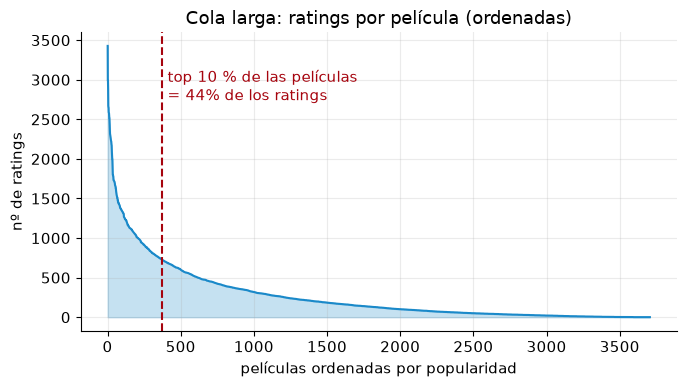

In [21]:
print(f"densidad = {ml.R.nnz:,} / ({ml.n_users:,} × {ml.n_items:,}) = {ml.R.nnz / (ml.n_users * ml.n_items):.2%}")
plot_long_tail()

**Cola larga:** pocas películas concentran gran parte de los ratings. Cualquier modelo tenderá a recomendar lo popular; por eso la **popularidad** es el baseline obligatorio.

**📝 Ejemplo 7.** ¿Qué fracción de los ratings se vuelve "positiva" con la regla rating ≥ 4? Basta una línea:

In [22]:
share_positive = (ml.ratings["rating"] >= 4).mean()
print(f"{share_positive:.1%} de los ratings son >= 4 -> positivos")

57.5% de los ratings son >= 4 -> positivos


**Respuesta.** Algo más de la mitad. El resto (notas 1–3) se trata como "no observado".

<a name="5"></a>
## 5. Evaluar sin hacer trampa: split por tiempo

Para cada usuario, ordenamos sus películas positivas por fecha:

- las **últimas 5** → **test** (el "futuro" que queremos predecir; solo se mira al final);
- las **5 anteriores** → **validación** (para elegir hiperparámetros);
- el resto → **train**.

Así el modelo nunca aprende con preferencias que todavía no existían (igual que en la S3).

usuarios evaluados: 5,656 | train 514,408 | validación 28,280 | test 28,280


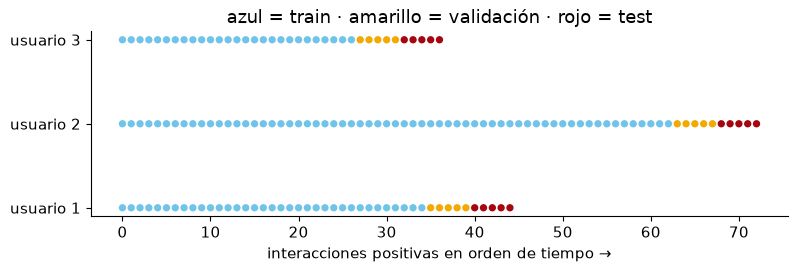

In [23]:
split = temporal_split(ml.ratings, threshold=4)
print(f"usuarios evaluados: {len(split.eval_users):,} | train {split.X_train.nnz:,} | "
      f"validación {len(split.val_df):,} | test {len(split.test_df):,}")
plot_split(split)

💬 **Ejemplo 8 — discuta.** Suponga un split **aleatorio** de interacciones: un usuario vio *Toy Story 2* en enero y *Toy Story* en marzo; *Toy Story* queda en train y *Toy Story 2* en test. ¿Qué problema hay? ¿El número de test sería optimista o pesimista?

**Respuesta.** El modelo aprende de marzo para "predecir" enero: usa información del futuro. Las métricas salen **optimistas** y no se repiten en producción, donde solo existe el pasado.

<a name="6"></a>
## 6. Baselines: lo que hay que superar

| Modelo | Cómo puntúa |
|---|---|
| aleatorio | números al azar (el piso) |
| popularidad | cuántas personas vieron la película: la misma lista para todos |
| item-item | el colaborativo del ejercicio 3, a escala |
| contenido | el perfil de géneros del ejercicio 2, a escala |

Las métricas son las del ejercicio 5, con $k = 10$, promediadas sobre ≈ 5 600 usuarios. **Coverage** = fracción del catálogo que aparece en alguna lista.

🔮 **Prediga:** ordene los cuatro de mejor a peor en NDCG@10.

In [24]:
X, truth, users = split.X_trainval, split.test_truth, split.eval_users
recs = {name: top_k_from_scores(scorer(X, users), X, users)
        for name, scorer in [("aleatorio", random_scores), ("popularidad", popularity_scores),
                             ("item-item", item_item_scores), ("contenido", content_scores)]}
results = [evaluate(name, r, truth, ml.n_items) for name, r in recs.items()]
pd.DataFrame(results).set_index("model")

,precision@10,recall@10,ndcg@10,coverage
model,,,,
aleatorio,0.0016,0.0031,0.0023,1.0000
popularidad,0.0214,0.0429,0.0347,0.0318
item-item,0.0326,0.0653,0.0553,0.0947
contenido,0.0062,0.0124,0.0095,0.7928


**📝 Ejemplo 9 — ¿son malos esos números?** Un NDCG de 0,05 parece bajo. Calculemos la **precisión@10 al azar**: cada usuario tiene 5 películas de test entre ≈ 3 700. La probabilidad de que un ítem al azar sea relevante es ≈ $5 / 3\,700$.

In [25]:
random_precision = N_TEST / ml.n_items
print(f"precision@10 esperada al azar ≈ {N_TEST} / {ml.n_items:,} = {random_precision:.4f}")

precision@10 esperada al azar ≈ 5 / 3,706 = 0.0013


**Respuesta.** $5 / 3\,706 \approx 0{,}0013$, igual a la fila "aleatorio". Item-item es ≈ 20 veces mejor que el azar. Los valores absolutos dependen del tamaño del catálogo: lo que se compara es la **mejora frente al baseline**.

In [26]:
example_user = split.eval_users[0]
print("Algunas películas que le gustaron:", *ml.titles.reindex(X[example_user].indices[:6]), sep="\n  ")
lists_side_by_side(example_user, {m: recs[m] for m in ["popularidad", "item-item", "contenido"]})

Algunas películas que le gustaron:
  Toy Story (1995)
  Apollo 13 (1995)
  Star Wars: Episode IV - A New Hope (1977)
  Schindler's List (1993)
  Secret Garden, The (1993)
  Aladdin (1992)


,popularidad,item-item,contenido
0,American Beauty (1999),Star Wars: Episode V - The Empire Strikes Back...,Wide Awake (1998)
1,Star Wars: Episode V - The Empire Strikes Back...,Raiders of the Lost Ark (1981),Babe (1995)
2,Raiders of the Lost Ark (1981),"Shawshank Redemption, The (1994)",Pollyanna (1960)
3,"Silence of the Lambs, The (1991)","Silence of the Lambs, The (1991)",Kim (1950)
4,"Matrix, The (1999)","Princess Bride, The (1987)","Little Princess, The (1939)"
5,Star Wars: Episode VI - Return of the Jedi (1983),Pulp Fiction (1994),Fluke (1995)
6,Terminator 2: Judgment Day (1991),Groundhog Day (1993),"Parent Trap, The (1998)"
7,"Shawshank Redemption, The (1994)",American Beauty (1999),So Dear to My Heart (1949)
8,"Godfather, The (1972)",When Harry Met Sally... (1989),"Little Princess, A (1995)"
9,Braveheart (1995),Ghostbusters (1984),Prancer (1989)


💬 **Discuta:** ¿cuál de las tres listas se parece más a la historia de este usuario? ¿Qué lista recibiría cualquier otro usuario con popularidad?

<a name="7"></a>
## 7. ALS: aprender los vectores

**Idea:** un vector $\mathbf{u}_u$ por usuario y un $\mathbf{v}_i$ por película, de $f$ números, tales que $\mathbf{u}_u^\top \mathbf{v}_i$ sea alto donde hubo interacción y bajo donde no (lo que hicimos a mano en 3.3).

**Alternar:** con $V$ fijo, cada $\mathbf{u}_u$ es una regresión Ridge (features = vectores de películas, target = 1/0). Luego se fija $U$ y se resuelve $V$. Se repite.

| Fórmula (Hu, Koren y Volinsky, 2008) | Línea de código en `als_half_step` | Por qué |
|---|---|---|
| $V^\top C_u V = V^\top V + V^\top(C_u - I)V$ | `A = YtY + alpha * (Yu.T @ Yu) + lam * I` | $C_u - I$ vale $\alpha$ en lo visto y 0 en lo demás |
| $V^\top C_u\,\mathbf{p}_u$ | `b = (1 + alpha) * Yu.sum(axis=0)` | $p = 1$ y $c = 1 + \alpha$ solo en lo visto |
| $\mathbf{u}_u = A^{-1}\mathbf{b}$ | `np.linalg.solve(A, b)` | resolver es más estable que invertir |

Son exactamente las tres líneas de la celda 3.3; la función de las herramientas las repite para cada usuario y cada película.

🔮 **Prediga:** cada medio paso resuelve exactamente un problema de mínimos cuadrados. ¿Puede la pérdida subir de una iteración a la siguiente?

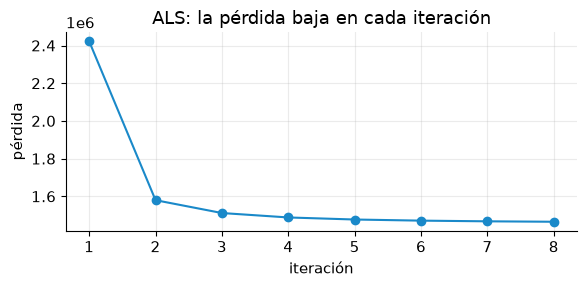

In [27]:
U, V, losses = fit_als(split.X_train, factors=32, lam=10.0, alpha=10.0, track_loss=True)
plot_loss(losses)

No puede subir: cada paso solo mejora. Tras pocas iteraciones casi no cambia, por eso bastan 10–15.

### Elegir hiperparámetros con validación

| Hiperparámetro | Si sube… |
|---|---|
| `factors` ($f$) | más capacidad, más riesgo de sobreajuste |
| `lam` ($\lambda$) | vectores más pequeños (más regularización) |
| `alpha` ($\alpha$) | más peso a lo visto frente a lo no visto |

In [28]:
def val_ndcg(factors, lam, alpha):
    U, V = fit_als(split.X_train, factors, lam, alpha)
    r = top_k_from_scores(U[split.val_users] @ V.T, split.X_train, split.val_users)
    return ndcg_at_k(r, split.val_truth)


grid = [(32, 10.0, 10.0), (32, 10.0, 40.0), (64, 10.0, 10.0), (64, 50.0, 10.0)]
search = pd.DataFrame([{"factors": f, "lam": l, "alpha": a, "val_ndcg@10": val_ndcg(f, l, a)} for f, l, a in grid])
search.sort_values("val_ndcg@10", ascending=False)

,factors,lam,alpha,val_ndcg@10
3,64,50.0000,10.0000,0.0681
2,64,10.0000,10.0000,0.0654
0,32,10.0000,10.0000,0.0646
1,32,10.0000,40.0000,0.0554


**📝 Ejemplo 10 — una configuración fuera de la grilla.** Menos factores y menos confianza en lo visto (`factors=16`, `alpha=1`). ¿Supera a la mejor de la tabla?

In [29]:
my_config = dict(factors=16, lam=10.0, alpha=1.0)

print(f"{my_config} -> NDCG@10 validación = {val_ndcg(**my_config):.4f}")

{'factors': 16, 'lam': 10.0, 'alpha': 1.0} -> NDCG@10 validación = 0.0650


**Respuesta.** No: con 16 factores y $\alpha = 1$ sale ≈ 0,065, por debajo de la mejor de la grilla (≈ 0,068). Menos capacidad y menos confianza en lo visto empeoran un poco.

Con la mejor configuración se reentrena con train + validación y se evalúa **una vez** en test.

In [30]:
best = search.sort_values("val_ndcg@10", ascending=False).iloc[0]
ALS_PARAMS = dict(factors=int(best["factors"]), lam=float(best["lam"]), alpha=float(best["alpha"]))
U_full, V_full = fit_als(split.X_trainval, **ALS_PARAMS)
als_scores_test = U_full[users] @ V_full.T
recs["ALS"] = top_k_from_scores(als_scores_test, X, users)
results.append(evaluate("ALS", recs["ALS"], truth, ml.n_items))
print("ALS:", ALS_PARAMS)
pd.DataFrame(results).set_index("model")

ALS: {'factors': 64, 'lam': 50.0, 'alpha': 10.0}


,precision@10,recall@10,ndcg@10,coverage
model,,,,
aleatorio,0.0016,0.0031,0.0023,1.0000
popularidad,0.0214,0.0429,0.0347,0.0318
item-item,0.0326,0.0653,0.0553,0.0947
contenido,0.0062,0.0124,0.0095,0.7928
ALS,0.0385,0.0769,0.0619,0.3025


In [31]:
lists_side_by_side(example_user, {m: recs[m] for m in ["popularidad", "item-item", "ALS"]})

,popularidad,item-item,ALS
0,American Beauty (1999),Star Wars: Episode V - The Empire Strikes Back...,American Beauty (1999)
1,Star Wars: Episode V - The Empire Strikes Back...,Raiders of the Lost Ark (1981),"Silence of the Lambs, The (1991)"
2,Raiders of the Lost Ark (1981),"Shawshank Redemption, The (1994)","Shawshank Redemption, The (1994)"
3,"Silence of the Lambs, The (1991)","Silence of the Lambs, The (1991)",Raiders of the Lost Ark (1981)
4,"Matrix, The (1999)","Princess Bride, The (1987)","Little Mermaid, The (1989)"
5,Star Wars: Episode VI - Return of the Jedi (1983),Pulp Fiction (1994),Amadeus (1984)
6,Terminator 2: Judgment Day (1991),Groundhog Day (1993),"Lion King, The (1994)"
7,"Shawshank Redemption, The (1994)",American Beauty (1999),Babe (1995)
8,"Godfather, The (1972)",When Harry Met Sally... (1989),"Princess Bride, The (1987)"
9,Braveheart (1995),Ghostbusters (1984),"Breakfast Club, The (1985)"


**📝 Ejemplo 11 — ¿qué aprendió ALS?** Nadie le dijo a ALS los géneros. Proyectamos los vectores de las 600 películas más vistas a 2D.

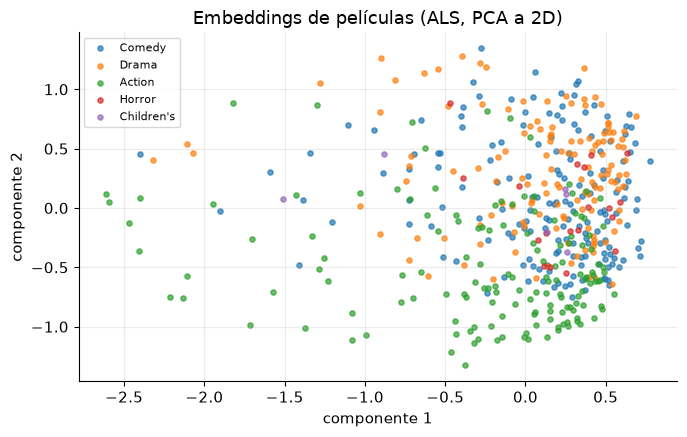

In [32]:
plot_item_embeddings(V_full, X)

💬 ¿Se agrupan por género? Si sí, ¿de dónde sacó ALS esa información? (Pista: Carla y Diego.) Estos vectores son el puente a la S5 (reducción de dimensión y clustering).

**Pausa: verifique** — mañana se registra un usuario nuevo. ¿Qué vector $\mathbf{u}$ tiene en ALS? ¿Qué parte del mini-mundo resolvía ese problema?

**Respuesta.** Ninguno hasta reentrenar (cold start). El contenido (Frozen, sección 3.2) funciona sin historia de interacciones.

<a name="8"></a>
## 8. Híbridos: contenido + colaborativo

**Híbrido ponderado:** $\text{score} = \beta \cdot \text{ALS} + (1 - \beta) \cdot \text{contenido}$ (ambos escalados a [0, 1]). $\beta = 1$ es ALS puro, $\beta = 0$ solo contenido.

**📝 Ejemplo 12.** Recorremos varios $\beta$ en **validación**. ¿Cuál maximiza NDCG? ¿Qué pasa con la cobertura cuando $\beta$ baja?

In [33]:
U_tr, V_tr = fit_als(split.X_train, **ALS_PARAMS)
vu = split.val_users
als_val, cont_val = minmax_rows(U_tr[vu] @ V_tr.T), content_scores(split.X_train, vu)

betas = [0.5, 0.7, 0.8, 0.9, 0.95, 1.0]
rows = []
for b in betas:
    r = top_k_from_scores(b * als_val + (1 - b) * cont_val, split.X_train, vu)
    rows.append({"beta": b, "val_ndcg@10": ndcg_at_k(r, split.val_truth), "coverage": coverage(r, ml.n_items)})
beta_table = pd.DataFrame(rows)
beta_table

,beta,val_ndcg@10,coverage
0,0.5000,0.0625,0.3462
1,0.7000,0.0676,0.3206
2,0.8000,0.0682,0.3108
3,0.9000,0.0683,0.3030
4,0.9500,0.0680,0.2998
5,1.0000,0.0681,0.2960


In [34]:
beta = float(beta_table.loc[beta_table["val_ndcg@10"].idxmax(), "beta"])
hybrid = beta * minmax_rows(als_scores_test) + (1 - beta) * content_scores(X, users)
recs["híbrido ponderado"] = top_k_from_scores(hybrid, X, users)
results.append(evaluate(f"híbrido ponderado (beta={beta})", recs["híbrido ponderado"], truth, ml.n_items))
print("beta elegido en validación:", beta)

beta elegido en validación: 0.9


### Re-ranking: ALS propone, un modelo de boosting ordena

1. ALS propone **100 candidatas** por usuario.
2. Cada (usuario, candidata) se vuelve **una fila** con features: score y posición en ALS, similitud de contenido, popularidad, año, edad del usuario…
3. **label** = 1 si el usuario la vio en **validación** (test no se toca).
4. Un `LGBMRanker` (el boosting de la S2) aprende a reordenar. Solo compara candidatas **del mismo usuario** (`group`) y castiga los pares mal ordenados, más si el error está arriba (objetivo *lambdarank* ≈ optimizar NDCG).

Así se ve la tabla de un usuario:

In [35]:
train_cands = candidate_frame(U_tr, V_tr, split.X_train, split.val_users, split.val_truth)
test_cands = candidate_frame(U_full, V_full, X, users)

u0 = train_cands["u"].iloc[0]
view = train_cands[train_cands["u"] == u0].assign(title=lambda d: ml.titles.reindex(d["i"]).to_numpy())
view[["title", "als_rank", "als_score", "content_sim", "item_popularity", "label"]].sort_values("label", ascending=False).head(8)

,title,als_rank,als_score,content_sim,item_popularity,label
38,Aladdin (1992),39,0.4936,0.5449,6.7250,1
1,Schindler's List (1993),2,0.8716,0.5780,7.5491,1
5,Beauty and the Beast (1991),6,0.7035,0.4719,6.4877,1
79,"Bug's Life, A (1998)",80,0.3562,0.4719,6.9613,1
27,Toy Story (1995),28,0.5747,0.4719,7.3139,1
0,"Silence of the Lambs, The (1991)",1,0.8932,0.6055,7.6266,0
73,Dances with Wolves (1990),74,0.3678,0.5169,6.8156,0
72,"Straight Story, The (1999)",73,0.3713,0.7785,5.6836,0


💬 Las películas con `label = 1` no están todas arriba en `als_rank`. ¿Qué tendría que aprender el ranker para subirlas?

In [36]:
ranker = LGBMRanker(objective="lambdarank", n_estimators=200, learning_rate=0.05, num_leaves=31,
                    min_child_samples=50, random_state=RANDOM_STATE, verbose=-1)
ranker.fit(train_cands[FEATURES], train_cands["label"], group=train_cands.groupby("u").size().to_numpy())

test_cands["rerank_score"] = ranker.predict(test_cands[FEATURES])
recs["re-ranking"] = {u: list(g.nlargest(K, "rerank_score")["i"]) for u, g in test_cands.groupby("u")}
results.append(evaluate("re-ranking (ALS + LGBMRanker)", recs["re-ranking"], truth, ml.n_items))
comparison = pd.DataFrame(results).set_index("model")
comparison

,precision@10,recall@10,ndcg@10,coverage
model,,,,
aleatorio,0.0016,0.0031,0.0023,1.0000
popularidad,0.0214,0.0429,0.0347,0.0318
item-item,0.0326,0.0653,0.0553,0.0947
contenido,0.0062,0.0124,0.0095,0.7928
ALS,0.0385,0.0769,0.0619,0.3025
híbrido ponderado (beta=0.9),0.0379,0.0758,0.0615,0.3135
re-ranking (ALS + LGBMRanker),0.0392,0.0785,0.0634,0.4304


💬 **Discuta con la tabla:**

1. ¿Qué modelo desplegaría para la página de inicio? ¿Y para vender la cola larga del catálogo?
2. El contenido solo tiene NDCG bajo pero coverage alta. ¿Por qué?
3. Todas las filas usan el mismo split, usuarios y $k$. ¿Por qué eso es indispensable para comparar?

<a name="9"></a>
## 9. SHAP: ¿por qué el ranker ordenó así?

Los factores de ALS no tienen nombre; las features del ranker sí. SHAP reparte el score de cada candidata entre las features.

**Idea (teoría de juegos):** Ana y Beto ganan 100 puntos en trivia; solos sacarían 60 y 20. ¿Cuánto mérito tiene cada uno? Armamos el equipo **de a uno** y medimos cuántos puntos sube al **unirse** cada persona. Si entra Ana primero: Ana +60, Beto +40. Si entra Beto primero: Beto +20, Ana +80. Promedio: **Ana 70, Beto 30** (suman 100).

En SHAP los jugadores son las **features** y el premio es cuánto se aleja el score del promedio. Una feature que todavía no "entró" toma su valor promedio.

Ranker de juguete: $f(\text{als}, \text{pop}) = 2\,\text{als} + \text{pop} + \text{als}\cdot\text{pop}$. Promedio: als = pop = 0,5, así que $\phi_0 = f(0{,}5;\ 0{,}5) = 1{,}75$.

Ejemplo resuelto, Elena–Die Hard (als = 0,9, pop = 0,4):

In [37]:
def toy_ranker(als, pop):
    return 2 * als + pop + als * pop

ref = {"als": 0.5, "pop": 0.5}
x_die_hard = {"als": 0.9, "pop": 0.4}
phi = shapley(toy_ranker, x_die_hard, ref)
print("phi_0 =", toy_ranker(**ref), "| phi =", {k: round(v, 2) for k, v in phi.items()},
      "| phi_0 + suma =", round(toy_ranker(**ref) + sum(phi.values()), 2), "| f(x) =", round(toy_ranker(**x_die_hard), 2))

phi_0 = 1.75 | phi = {'als': 0.98, 'pop': -0.17} | phi_0 + suma = 2.56 | f(x) = 2.56


**📝 Ejemplo 13 — Shapley a mano.** Candidata Elena–Lion King: als = 0,6, pop = 0,7. La tabla y $\phi_{\text{als}}$, $\phi_{\text{pop}}$:

| Orden de entrada | cuánto sube al unirse als | cuánto sube al unirse pop |
|---|---|---|
| entra als, luego pop | $f(0{,}6;\,0{,}5) - f(0{,}5;\,0{,}5)$ | $f(0{,}6;\,0{,}7) - f(0{,}6;\,0{,}5)$ |
| entra pop, luego als | $f(0{,}6;\,0{,}7) - f(0{,}5;\,0{,}7)$ | $f(0{,}5;\,0{,}7) - f(0{,}5;\,0{,}5)$ |
| **promedio** | $\phi_{\text{als}}$ | $\phi_{\text{pop}}$ |

In [38]:
f = toy_ranker
als_first = {"als": f(0.6, 0.5) - f(0.5, 0.5), "pop": f(0.6, 0.7) - f(0.6, 0.5)}
pop_first = {"als": f(0.6, 0.7) - f(0.5, 0.7), "pop": f(0.5, 0.7) - f(0.5, 0.5)}
display(pd.DataFrame([als_first, pop_first], index=["entra als, luego pop", "entra pop, luego als"]).round(2))
phi_als = (als_first["als"] + pop_first["als"]) / 2
phi_pop = (als_first["pop"] + pop_first["pop"]) / 2
print(f"phi_als = {phi_als:.2f} | phi_pop = {phi_pop:.2f} | 1,75 + {phi_als:.2f} + {phi_pop:.2f} = {1.75 + phi_als + phi_pop:.2f} = f(x)")

,als,pop
"entra als, luego pop",0.2500,0.3200
"entra pop, luego als",0.2700,0.3000


phi_als = 0.26 | phi_pop = 0.31 | 1,75 + 0.26 + 0.31 = 2.32 = f(x)


**Respuesta.** $f(0{,}6;0{,}5) = 2{,}0$, $f(0{,}5;0{,}7) = 2{,}05$, $f(0{,}6;0{,}7) = 2{,}32$.
$\phi_{\text{als}} = \tfrac12[(2{,}0 - 1{,}75) + (2{,}32 - 2{,}05)] = 0{,}26$ · $\phi_{\text{pop}} = \tfrac12[(2{,}32 - 2{,}0) + (2{,}05 - 1{,}75)] = 0{,}31$.
Suma: $1{,}75 + 0{,}26 + 0{,}31 = 2{,}32 = f(x)$ (**eficiencia**). Aquí la popularidad aporta más que ALS: Lion King sube por ser popular, no por ser personal.

Con 10 features hay $10!$ órdenes; `TreeExplainer` hace el mismo cálculo de forma exacta y rápida para árboles.

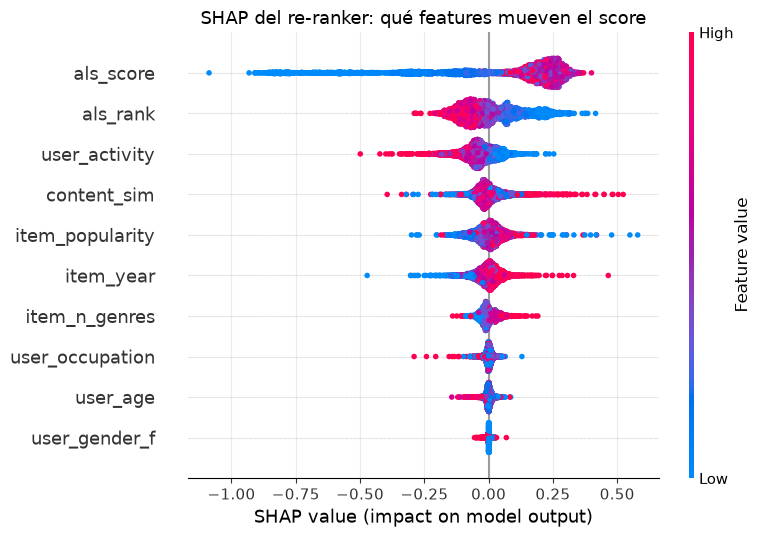

In [39]:
sample = test_cands.sample(4000, random_state=RANDOM_STATE)
if SHAP_AVAILABLE:
    explainer = shap.TreeExplainer(ranker)
    shap_values = explainer(sample[FEATURES])
    phi_real = shap_values.values
    shap.plots.beeswarm(shap_values, max_display=10, show=False)
    plt.title("SHAP del re-ranker: qué features mueven el score")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig_shap_beeswarm.png", dpi=150, bbox_inches="tight")
    plt.show()
else:  # LightGBM computes the same TreeSHAP contributions natively
    phi_real = ranker.predict(sample[FEATURES], pred_contrib=True)[:, :-1]

**Cómo leer el beeswarm:** cada punto = una candidata. Eje x = cuánto empuja la feature el score (derecha = sube en la lista). Color = valor de la feature (rojo alto, azul bajo). Filas ordenadas por importancia.

💬 **Ejemplo 14.** Mire `als_rank`: ¿los puntos azules (rango bajo = arriba en ALS) están a la derecha o a la izquierda? ¿Qué significa? ¿Y `item_popularity`?

**Respuesta.** En `als_rank` los puntos **azules** (puesto bajo = arriba en la lista de ALS) están a la **derecha**: el ranker sube lo que ALS ya ponía arriba. En `als_score` pasa lo mismo con los rojos (score alto → derecha) y los azules bajan mucho. En `item_popularity` los rojos (más popular) tienden a la derecha, pero con menos fuerza que ALS: la popularidad ayuda, no manda.

Ojo con `user_activity`, `user_age`, etc.: valen lo mismo para **todas** las candidatas de un usuario, así que mueven el score de todas por igual y casi no cambian el **orden** dentro de su lista.

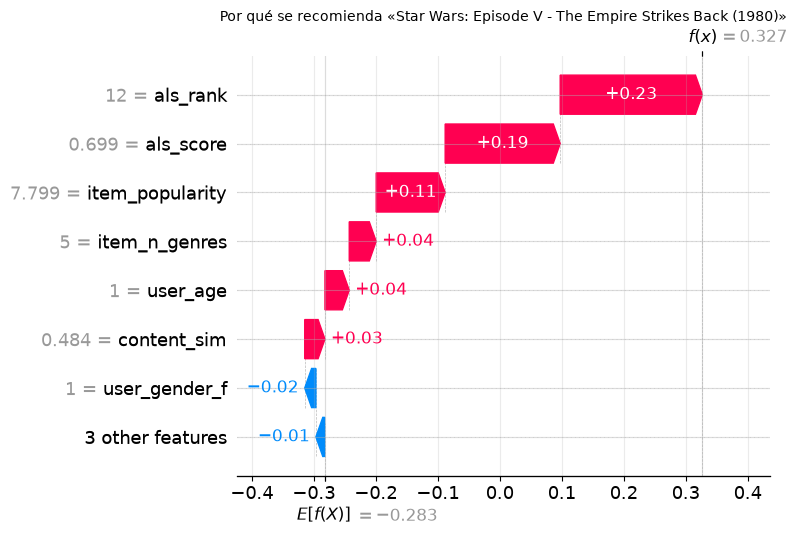

usuario 1 -> Star Wars: Episode V - The Empire Strikes Back (1980)


In [40]:
USER = example_user

row = test_cands[test_cands["u"] == USER].nlargest(1, "rerank_score")
title = ml.titles.loc[int(row["i"].iloc[0])]
if SHAP_AVAILABLE:
    shap.plots.waterfall(explainer(row[FEATURES])[0], max_display=8, show=False)
    plt.title(f"Por qué se recomienda «{title}»", fontsize=10)
    plt.tight_layout()
    if USER == example_user:
        plt.savefig(FIG_DIR / "fig_shap_waterfall.png", dpi=150, bbox_inches="tight")
    plt.show()
print(f"usuario {ml.user_ids[USER]} -> {title}")

**Cómo leer el waterfall:** abajo $E[f(x)]$ = score promedio ($\phi_0$); cada barra roja **sube**, cada azul **baja**; arriba queda $f(x)$. Es la tabla del ejercicio 13 con 10 features.

**📝 Ejemplo 15 — el "porque…" para este usuario.** La película sube de −0,28 (promedio) a +0,33. Lo que más la empuja: está **12.ª en ALS** (+0,23) y tiene **score ALS alto** (+0,19); después, que es **muy popular** (+0,11). La similitud de géneros aporta poco (+0,03).

Frase para el usuario: *"Porque a personas con gustos parecidos a los tuyos les gustó, y es una de las más vistas."* Lo que pesa es sobre todo **personal** (ALS), con un empujón **genérico** (popularidad).

Para ver otro caso, cambie `USER` en la celda anterior (por ejemplo `split.eval_users[10]`).

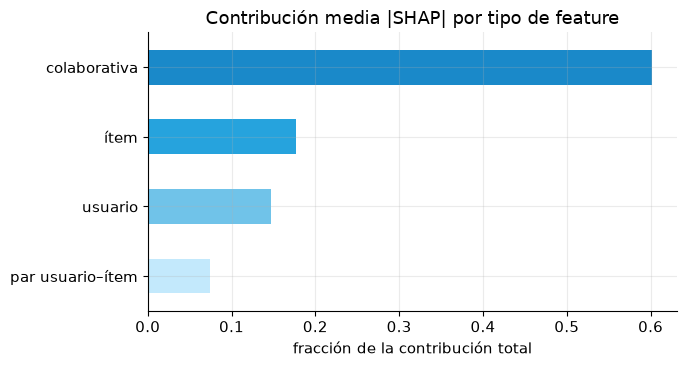

par usuario–ítem   0.0745
usuario            0.1473
ítem               0.1768
colaborativa       0.6014
dtype: float64

In [41]:
plot_shap_groups(phi_real)

💬 **Discuta:**

- Si domina lo **colaborativo**, el ranker refina ALS; si dominan las features del **ítem** (popularidad), personaliza poco.
- Si `user_age` o `user_gender_f` pesaran mucho, ¿qué revisaría antes de desplegar?
- SHAP explica **el modelo**, no la causa de la preferencia.

<a name="10"></a>
## 10. Para seguir practicando

0. **Mini-mundo:** agregue a Fabio, que solo vio *Alien* y *Die Hard*. Sin ejecutar: ¿qué le recomienda contenido? ¿Y item-item? Compruébelo modificando `toy_R`.
1. **Explícito frente a implícito:** entrene ALS con los ratings 1–5 (pérdida solo sobre las celdas observadas) y compare el top-N.
2. **Cold start:** evalúe solo usuarios con poca historia en train. ¿El híbrido ponderado supera a ALS ahí?
3. **Más features:** agregue al ranker la similitud con la **última** película vista. ¿Cambia el SHAP?
4. **Popularidad y equidad:** mida la popularidad media de lo recomendado por cada modelo. ¿Cuál concentra más el catálogo?
5. **`implicit`:** compare `fit_als` con `implicit.als.AlternatingLeastSquares` (mismos $f$, $\lambda$, $\alpha$).

**La frase que debe sobrevivir:** un recomendador merece confianza cuando se evalúa con un split que respeta el tiempo, supera al baseline de popularidad en métricas de ranking, cuida la cobertura y puede explicar **por qué** ordenó así.